# Netflix Viewership Analysis

## Project Overview

This project analyzes Netflix viewership data to identify patterns in global popularity, ranking longevity, ranking distribution, content variety by country, early viewership performance, and the relationship between runtime and audience engagement.

Three Netflix datasets are used to examine viewing behavior from multiple perspectives. The project produces six visualizations that highlight popular titles, long-running Top 10 content, country-level variety, and other viewership trends.


## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

## 2. Set Project Paths

In [2]:
CURRENT_DIR = Path.cwd()

# Support running from either the project root or the notebooks folder.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)

Project directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Netflix_Trend_Analysis
Data directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Netflix_Trend_Analysis\data
Figures directory: C:\Mathan\GitHub\Mathan-MS.github.io\mathan-ms.github.io\Projects\Netflix_Trend_Analysis\figures


## 3. Load the Datasets

In [3]:
countries_file = DATA_DIR / "all-weeks-countries-netflix.xlsx"
global_file = DATA_DIR / "all-weeks-global-netflix.xlsx"
popular_file = DATA_DIR / "most-popular-netflix.xlsx"

df_countries = pd.read_excel(countries_file)
df_global = pd.read_excel(global_file)
df_popular = pd.read_excel(popular_file)

print("All three Netflix datasets loaded successfully.")

print("\nCountries dataset:")
display(df_countries.head())

print("\nGlobal dataset:")
display(df_global.head())

print("\nMost popular dataset:")
display(df_popular.head())

All three Netflix datasets loaded successfully.

Countries dataset:


,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10
0,Argentina,AR,2024-04-14,Films,1,The Tearsmith,NaN,2
1,Argentina,AR,2024-04-14,Films,2,Stolen,NaN,1
2,Argentina,AR,2024-04-14,Films,3,"Love, Divided",NaN,1
3,Argentina,AR,2024-04-14,Films,4,Woody Woodpecker Goes to Camp,NaN,1
4,Argentina,AR,2024-04-14,Films,5,Rest In Peace,NaN,3



Global dataset:


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details
0,2024-04-14,Films (English),1,What Jennifer Did,NaN,26100000,1.4500,18000000.0,1,False,NaN
1,2024-04-14,Films (English),2,Woody Woodpecker Goes to Camp,NaN,19600000,1.6667,11800000.0,1,False,NaN
2,2024-04-14,Films (English),3,Scoop,NaN,14600000,1.7167,8500000.0,2,False,NaN
3,2024-04-14,Films (English),4,Glass,NaN,11000000,2.1500,5100000.0,2,False,NaN
4,2024-04-14,Films (English),5,Megan Leavey,NaN,9700000,1.9333,5000000.0,1,False,NaN



Most popular dataset:


,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days
0,Films (English),1,Red Notice,NaN,454200000,1.9667,230900000
1,Films (English),2,Don't Look Up,NaN,408600000,2.3833,171400000
2,Films (English),3,The Adam Project,NaN,281000000,1.7833,157600000
3,Films (English),4,Bird Box,NaN,325300000,2.0667,157400000
4,Films (English),5,Leave the World Behind,NaN,339300000,2.3667,143400000


## 4. Clean and Prepare the Data

In [4]:
# Standardize column names
df_countries.columns = df_countries.columns.str.strip().str.lower()
df_global.columns = df_global.columns.str.strip().str.lower()
df_popular.columns = df_popular.columns.str.strip().str.lower()

# Convert week columns to datetime
df_countries["week"] = pd.to_datetime(
    df_countries["week"],
    errors="coerce"
)

df_global["week"] = pd.to_datetime(
    df_global["week"],
    errors="coerce"
)

# Create a combined title column
df_countries["title"] = df_countries["show_title"].fillna("")
mask = df_countries["season_title"].notna()
df_countries.loc[mask, "title"] = (
    df_countries.loc[mask, "show_title"]
    + " - "
    + df_countries.loc[mask, "season_title"]
)

df_global["title"] = df_global["show_title"].fillna("")
mask = df_global["season_title"].notna()
df_global.loc[mask, "title"] = (
    df_global.loc[mask, "show_title"]
    + " - "
    + df_global.loc[mask, "season_title"]
)

df_popular["title"] = df_popular["show_title"].fillna("")
mask = df_popular["season_title"].notna()
df_popular.loc[mask, "title"] = (
    df_popular.loc[mask, "show_title"]
    + " - "
    + df_popular.loc[mask, "season_title"]
)

# Convert numeric columns
df_global["weekly_views"] = pd.to_numeric(
    df_global["weekly_views"],
    errors="coerce"
)

df_popular["views_first_91_days"] = pd.to_numeric(
    df_popular["views_first_91_days"],
    errors="coerce"
)

# Remove duplicates
df_countries = df_countries.drop_duplicates()
df_global = df_global.drop_duplicates()
df_popular = df_popular.drop_duplicates()

print("Data cleaning completed successfully.")

Data cleaning completed successfully.


In [5]:
print("Countries dataset after cleaning:")
display(df_countries.head())

print("\nGlobal dataset after cleaning:")
display(df_global.head())

print("\nMost popular dataset after cleaning:")
display(df_popular.head())

Countries dataset after cleaning:


,country_name,country_iso2,week,category,weekly_rank,show_title,season_title,cumulative_weeks_in_top_10,title
0,Argentina,AR,2024-04-14,Films,1,The Tearsmith,NaN,2,The Tearsmith
1,Argentina,AR,2024-04-14,Films,2,Stolen,NaN,1,Stolen
2,Argentina,AR,2024-04-14,Films,3,"Love, Divided",NaN,1,"Love, Divided"
3,Argentina,AR,2024-04-14,Films,4,Woody Woodpecker Goes to Camp,NaN,1,Woody Woodpecker Goes to Camp
4,Argentina,AR,2024-04-14,Films,5,Rest In Peace,NaN,3,Rest In Peace



Global dataset after cleaning:


,week,category,weekly_rank,show_title,season_title,weekly_hours_viewed,runtime,weekly_views,cumulative_weeks_in_top_10,is_staggered_launch,episode_launch_details,title
0,2024-04-14,Films (English),1,What Jennifer Did,NaN,26100000,1.4500,18000000.0,1,False,NaN,What Jennifer Did
1,2024-04-14,Films (English),2,Woody Woodpecker Goes to Camp,NaN,19600000,1.6667,11800000.0,1,False,NaN,Woody Woodpecker Goes to Camp
2,2024-04-14,Films (English),3,Scoop,NaN,14600000,1.7167,8500000.0,2,False,NaN,Scoop
3,2024-04-14,Films (English),4,Glass,NaN,11000000,2.1500,5100000.0,2,False,NaN,Glass
4,2024-04-14,Films (English),5,Megan Leavey,NaN,9700000,1.9333,5000000.0,1,False,NaN,Megan Leavey



Most popular dataset after cleaning:


,category,rank,show_title,season_title,hours_viewed_first_91_days,runtime,views_first_91_days,title
0,Films (English),1,Red Notice,NaN,454200000,1.9667,230900000,Red Notice
1,Films (English),2,Don't Look Up,NaN,408600000,2.3833,171400000,Don't Look Up
2,Films (English),3,The Adam Project,NaN,281000000,1.7833,157600000,The Adam Project
3,Films (English),4,Bird Box,NaN,325300000,2.0667,157400000,Bird Box
4,Films (English),5,Leave the World Behind,NaN,339300000,2.3667,143400000,Leave the World Behind


## 5. Top 10 Most Viewed Netflix Titles Globally

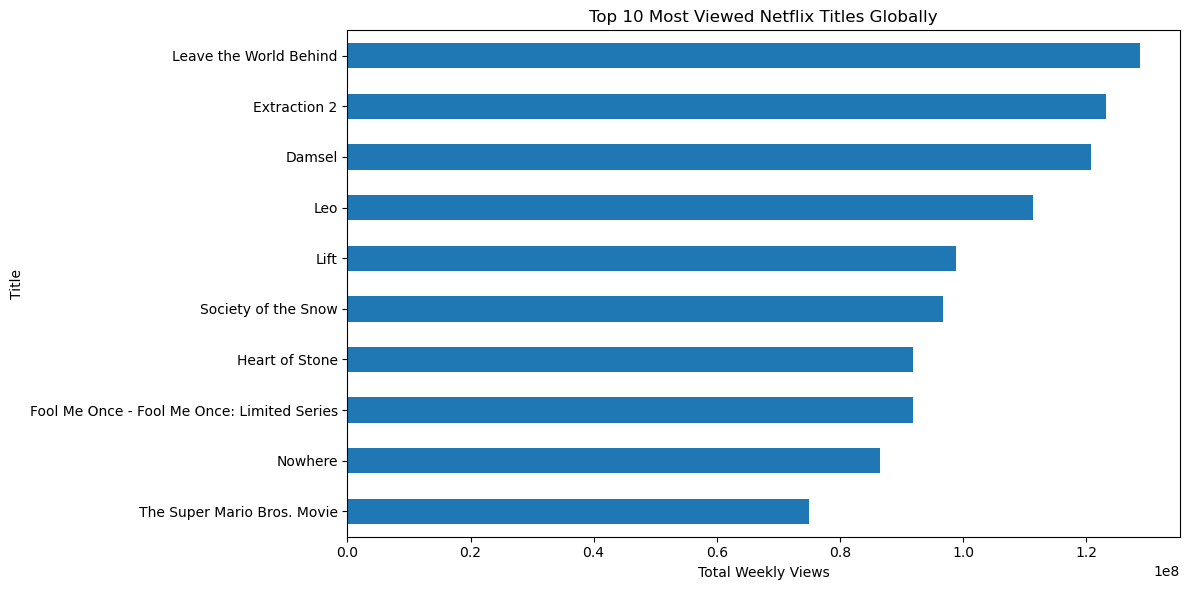

Saved: figures/top10_most_viewed_titles_globally.jpg


In [6]:
top10_views = (
    df_global.groupby("title")["weekly_views"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
top10_views.sort_values().plot(kind="barh")

plt.title("Top 10 Most Viewed Netflix Titles Globally")
plt.xlabel("Total Weekly Views")
plt.ylabel("Title")
plt.tight_layout()

save_path = FIGURES_DIR / "top10_most_viewed_titles_globally.jpg"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/top10_most_viewed_titles_globally.jpg")

### Observation

The visualization shows that a limited number of titles attract a particularly large share of viewing activity. Titles such as *Leave the World Behind* and *Extraction 2* stand out among the most viewed content.

From a business perspective, Netflix can use this information to identify content types that generate strong audience interest and support decisions related to content investment, promotion, and customer retention.


## 6. Weeks Titles Remain in the Top 10

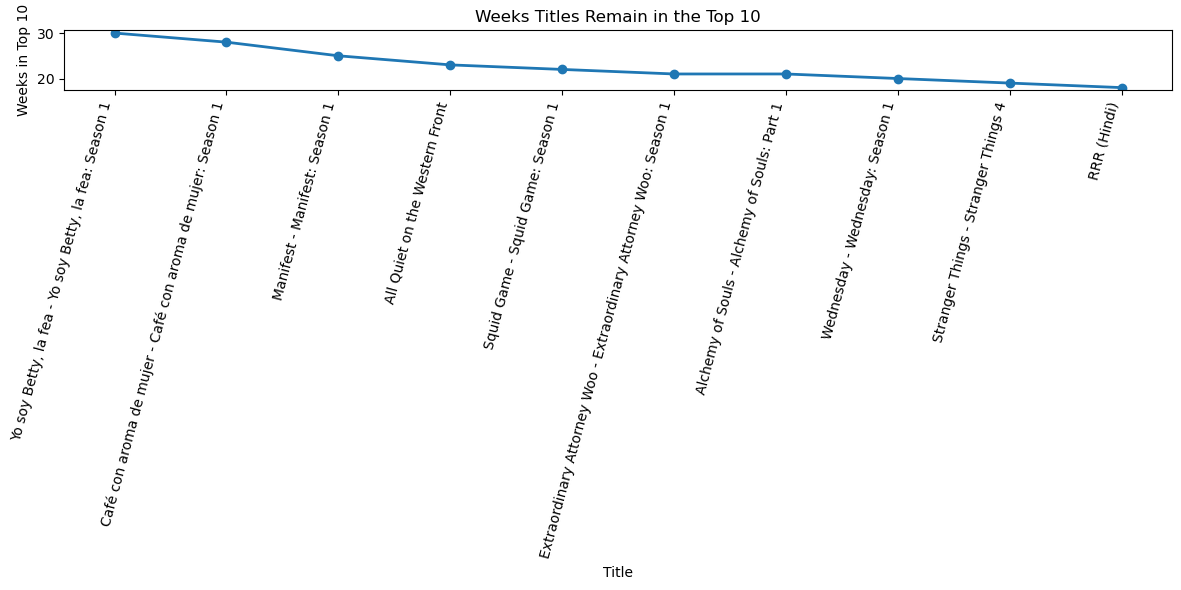

Saved: figures/weeks_titles_remain_in_top10.jpg


In [7]:
weeks_top10 = (
    df_global.groupby("title")["cumulative_weeks_in_top_10"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.plot(
    weeks_top10.index,
    weeks_top10.values,
    marker="o",
    linewidth=2
)

plt.title("Weeks Titles Remain in the Top 10")
plt.xlabel("Title")
plt.ylabel("Weeks in Top 10")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()

save_path = FIGURES_DIR / "weeks_titles_remain_in_top10.jpg"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/weeks_titles_remain_in_top10.jpg")

### Observation

The visualization highlights titles that remained in the Netflix Top 10 for the longest periods. Content such as *Yo Soy Betty, la fea* and *Manifest* demonstrates sustained audience interest.

Long-running popularity can be valuable because content that continues attracting viewers may support engagement and subscriber retention over a longer period.


## 7. Distribution of Ranking Levels

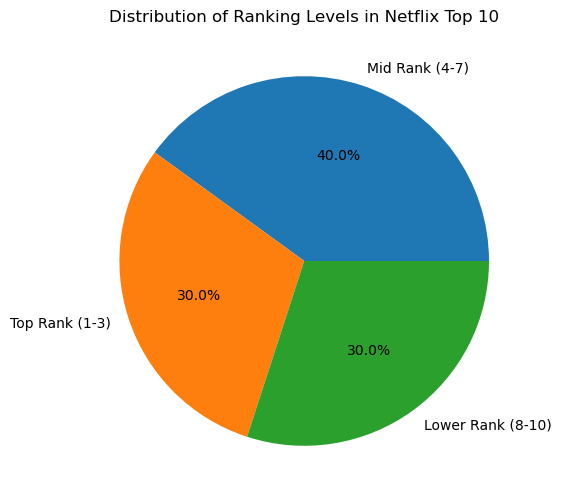

Saved: figures/distribution_of_ranking_levels.jpg


In [8]:
rank_group = pd.cut(
    df_countries["weekly_rank"],
    bins=[0, 3, 7, 10],
    labels=[
        "Top Rank (1-3)",
        "Mid Rank (4-7)",
        "Lower Rank (8-10)"
    ]
)

rank_distribution = rank_group.value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    rank_distribution,
    labels=rank_distribution.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Ranking Levels in Netflix Top 10")

save_path = FIGURES_DIR / "distribution_of_ranking_levels.jpg"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/distribution_of_ranking_levels.jpg")

### Observation

The ranking distribution shows that many titles appear in the middle positions of the Top 10 rather than consistently occupying the top three positions.

This can help identify opportunities to study what distinguishes highly ranked titles from mid-ranked titles and how promotion or audience targeting may influence ranking performance.


## 8. Content Variety by Country

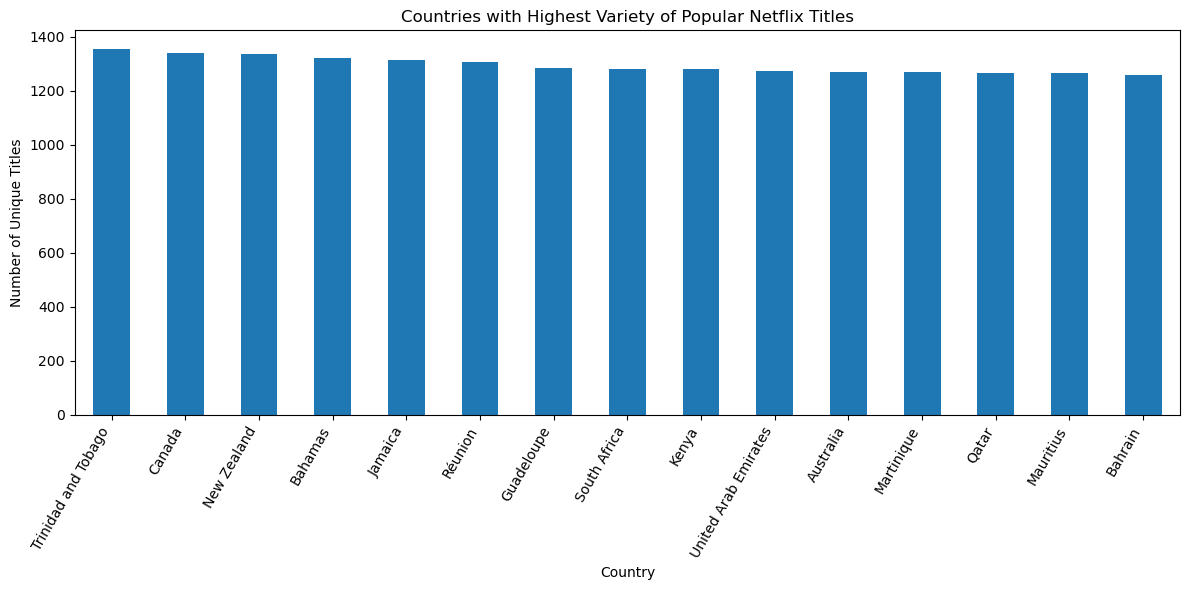

Saved: figures/content_variety_by_country.jpg


In [9]:
country_variety = (
    df_countries.groupby("country_name")["title"]
    .nunique()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
country_variety.plot(kind="bar")

plt.title("Countries with Highest Variety of Popular Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Unique Titles")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()

save_path = FIGURES_DIR / "content_variety_by_country.jpg"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/content_variety_by_country.jpg")

### Observation

The visualization shows countries with a large number of unique titles appearing in the Netflix Top 10. Countries such as Trinidad and Tobago, Canada, and New Zealand show broad content variety.

A diverse mix of popular content may help Netflix serve different audience preferences and support engagement across international markets.


## 9. Most Popular Titles in the First 91 Days

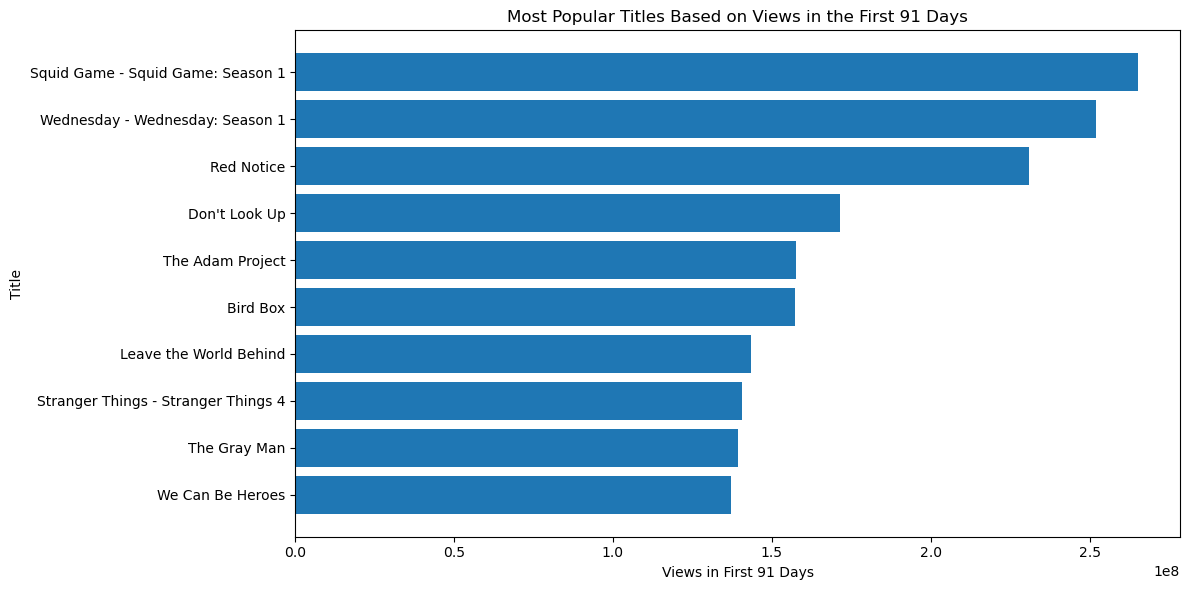

Saved: figures/most_popular_titles_first_91_days.jpg


In [10]:
popular_titles = (
    df_popular.sort_values(
        "views_first_91_days",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))
plt.barh(
    popular_titles["title"],
    popular_titles["views_first_91_days"]
)

plt.gca().invert_yaxis()
plt.title("Most Popular Titles Based on Views in the First 91 Days")
plt.xlabel("Views in First 91 Days")
plt.ylabel("Title")
plt.tight_layout()

save_path = FIGURES_DIR / "most_popular_titles_first_91_days.jpg"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/most_popular_titles_first_91_days.jpg")

### Observation

The visualization shows that titles such as *Squid Game* and *Wednesday* achieved very high viewership within the first 91 days.

Strong early performance demonstrates the importance of blockbuster content and effective launch strategies. High-performing releases can increase audience attention, strengthen the Netflix brand, and support subscriber engagement.


## 10. Runtime vs. Views

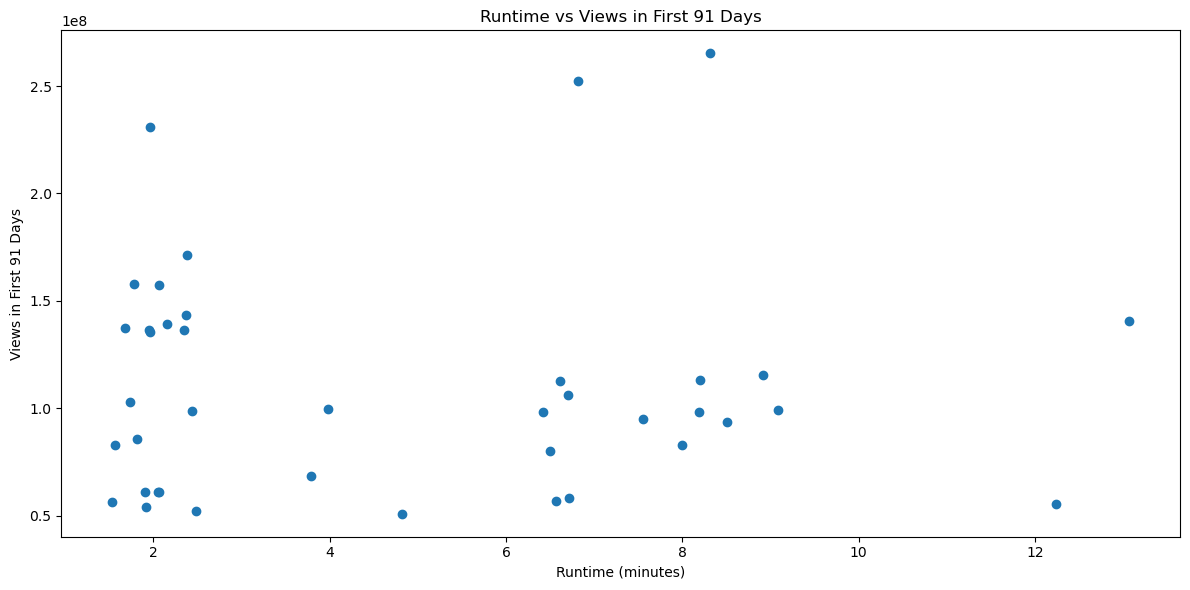

Saved: figures/runtime_vs_views.jpg


In [11]:
scatter_data = df_popular[
    ["runtime", "views_first_91_days"]
].dropna()

plt.figure(figsize=(12, 6))
plt.scatter(
    scatter_data["runtime"],
    scatter_data["views_first_91_days"]
)

plt.title("Runtime vs Views in First 91 Days")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Views in First 91 Days")
plt.tight_layout()

save_path = FIGURES_DIR / "runtime_vs_views.jpg"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/runtime_vs_views.jpg")

### Observation

The scatter plot suggests that highly viewed content exists across different runtime lengths. The visualization does not show a clear linear relationship between runtime and views in the first 91 days.

This indicates that runtime alone does not appear to determine popularity. Netflix can therefore focus on content quality and audience appeal rather than assuming that a particular runtime will generate stronger viewership.


## 11. Saved Project Outputs

In [12]:
print("Figures saved:")
for file in sorted(FIGURES_DIR.glob("*.jpg")):
    print(" -", file.name)

Figures saved:
 - content_variety_by_country.jpg
 - distribution_of_ranking_levels.jpg
 - most_popular_titles_first_91_days.jpg
 - runtime_vs_views.jpg
 - top10_most_viewed_titles_globally.jpg
 - weeks_titles_remain_in_top10.jpg


## Conclusion

This project uses Netflix viewership data to examine popularity, ranking longevity, country-level content variety, early viewership performance, and runtime relationships.

The visualizations show that a relatively small number of titles can generate strong global interest, while some titles maintain popularity over longer periods. The analysis also suggests that content variety differs across countries and that runtime alone does not determine early viewership success.

These insights can support content strategy, promotion, audience engagement, and international programming decisions.
